In [5]:
pip install yfinance

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.2/949.2 kB 16.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 112.3 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15636 sha256=703b2a306a995857e1c7e7d67f829417c9da621411cd4a63405ac13fa68038c2
  Stored in directory: /root/.cache/pip/wheels/42/d6/84/bf57a755f4569494cd00de4bb46ef064874823f4d19c82e960
  Created wheel for peewee: filename=peewee-3.18.2-cp311-cp311-linux_x86_64.whl size=886654 sha256=3922448909577045c579ac210ce329531cba1b85de1e4f5f157cef8ae566a43a
  Stored in directory: /root/.cache/pip/wheels/28/84/61/

In [6]:
import numpy as np


In [10]:




import yfinance as yf
from datetime import datetime, timedelta

# 获取昨天的日期
end_date = datetime.today() - timedelta(days=1)
start_date = end_date - timedelta(days=365 * 3)

# 格式化为字符串形式（yfinance需要）
start_str = start_date.strftime('%Y-%m-%d')
end_str = end_date.strftime('%Y-%m-%d')

# 下载江西铜业的股票数据
ticker = "600362.SS"
data = yf.download(ticker, start=start_str, end=end_str)

# 保存为CSV文件
data.to_csv('recent_stock_prices.csv')
print(f"数据已保存到 recent_stock_prices.csv（从 {start_str} 到 {end_str}）")


/tmp/ipython-input-528031313.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_str, end=end_str)
[*********************100%***********************]  1 of 1 completed

数据已保存到 recent_stock_prices.csv（从 2022-08-10 到 2025-08-09）


In [13]:
import pandas as pd

In [14]:
pf = pd.read_csv("recent_stock_prices.csv")
print(pf.head())

        Price               Close                High                 Low  \
0      Ticker           600362.SS           600362.SS           600362.SS   
1        Date                 NaN                 NaN                 NaN   
2  2022-08-10  15.658514022827148  15.943715600616384  15.584913559050136   
3  2022-08-11  15.916114807128906  15.925315084469954  15.695313415264199   
4  2022-08-12  15.962115287780762  16.081715376878595  15.897715104822439   

                 Open     Volume  
0           600362.SS  600362.SS  
1                 NaN        NaN  
2   15.78731439574355   11812927  
3  15.824115543265385   16656294  
4  15.934514457324319   13411574  


In [15]:
# 加载原始 CSV 文件
try:
    data = pd.read_csv('recent_stock_prices.csv')
    print("CSV 数据预览：")
    print(data.head())
except pd.errors.EmptyDataError:
    print("CSV 文件为空，请检查数据来源或重新下载。")
except FileNotFoundError:
    print("文件不存在，请确认文件路径是否正确。")

CSV 数据预览：
        Price               Close                High                 Low  \
0      Ticker           600362.SS           600362.SS           600362.SS   
1        Date                 NaN                 NaN                 NaN   
2  2022-08-10  15.658514022827148  15.943715600616384  15.584913559050136   
3  2022-08-11  15.916114807128906  15.925315084469954  15.695313415264199   
4  2022-08-12  15.962115287780762  16.081715376878595  15.897715104822439   

                 Open     Volume  
0           600362.SS  600362.SS  
1                 NaN        NaN  
2   15.78731439574355   11812927  
3  15.824115543265385   16656294  
4  15.934514457324319   13411574  


In [16]:
import pandas as pd

# 读取原始 CSV
df = pd.read_csv('recent_stock_prices.csv')

# 重命名列并删除前两行
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
df = df.iloc[2:].reset_index(drop=True)

# 转换数据类型
df[['Close', 'High', 'Low', 'Open', 'Volume']] = df[['Close', 'High', 'Low', 'Open', 'Volume']].astype(float)

# 日期格式转换
df['Date'] = pd.to_datetime(df['Date'])


In [17]:
df.to_csv('cleaned_stock_data.csv', index=False)
print(df.head())

        Date      Close       High        Low       Open      Volume
0 2022-08-10  15.658514  15.943716  15.584914  15.787314  11812927.0
1 2022-08-11  15.916115  15.925315  15.695313  15.824116  16656294.0
2 2022-08-12  15.962115  16.081715  15.897715  15.934514  13411574.0
3 2022-08-15  15.916115  15.989715  15.741315  15.814915  11770718.0
4 2022-08-16  15.814914  15.980515  15.759712  15.916113   8886976.0


In [18]:
from sklearn.preprocessing import MinMaxScaler


In [19]:
def generate_lstm_datasets_with_time(df, window_sizes=[30, 60, 90, 120], target_shift=15, save=True):
    """
    构造包含时间特征的 LSTM 数据集
    """
    # 确保 Date 是 datetime 类型
    df['Date'] = pd.to_datetime(df['Date'])

    # 构造时间特征
    df['dayofweek'] = df['Date'].dt.dayofweek       # 周几
    df['day'] = df['Date'].dt.day                   # 每月第几天
    df['month'] = df['Date'].dt.month               # 月份
    df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)  # 是否月末

    # 选择数值特征列 + 时间特征列
    feature_cols = ['Close', 'High', 'Low', 'Open', 'Volume',
                    'dayofweek', 'day', 'month', 'is_month_end']

    # 标准化所有特征
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[feature_cols].values)

    datasets = {}

    for window_size in window_sizes:
        X, y = [], []
        for i in range(len(scaled_data) - window_size - target_shift):
            window = scaled_data[i:i+window_size]
            current_close = scaled_data[i+window_size-1][0]
            future_close = scaled_data[i+window_size+target_shift-1][0]
            label = 1 if future_close > current_close else 0
            X.append(window)
            y.append(label)

        X = np.array(X)
        y = np.array(y)

        datasets[window_size] = {'X': X, 'y': y, 'scaler': scaler}

        if save:
            flat_X = X.reshape(X.shape[0], -1)
            df_out = pd.DataFrame(flat_X)
            df_out['label'] = y
            df_out.to_csv(f'lstm_data_with_time_{window_size}.csv', index=False)

    return datasets


In [20]:
datasets = generate_lstm_datasets_with_time(df, window_sizes=[30, 60, 90, 120], target_shift=15)


In [21]:
for window_size, data in datasets.items():
    X = data['X']
    y = data['y']
    print(f"🪟 窗口大小: {window_size}")
    print(f"📦 X 的形状: {X.shape}")  # (样本数, 时间步长, 特征数)
    print(f"🎯 y 的形状: {y.shape}")  # (样本数,)
    print("-" * 40)



🪟 窗口大小: 30
📦 X 的形状: (682, 30, 9)
🎯 y 的形状: (682,)
----------------------------------------
🪟 窗口大小: 60
📦 X 的形状: (652, 60, 9)
🎯 y 的形状: (652,)
----------------------------------------
🪟 窗口大小: 90
📦 X 的形状: (622, 90, 9)
🎯 y 的形状: (622,)
----------------------------------------
🪟 窗口大小: 120
📦 X 的形状: (592, 120, 9)
🎯 y 的形状: (592,)
----------------------------------------


In [22]:
    scaler = data['scaler']
    print(f"📊 使用的归一化器: {scaler}")


📊 使用的归一化器: MinMaxScaler()


In [23]:
for window_size, value in datasets.items():
    print(f"窗口大小: {window_size}")
    print(f"类型: {type(value)}")
    print(f"内容预览: {value}")
    print("-" * 40)


窗口大小: 30
类型: <class 'dict'>
内容预览: {'X': array([[[0.13993963, 0.14426135, 0.14623679, ..., 0.3       ,
         0.63636364, 0.        ],
        [0.15993091, 0.14283299, 0.15542435, ..., 0.33333333,
         0.63636364, 0.        ],
        [0.1635008 , 0.15497373, 0.17226838, ..., 0.36666667,
         0.63636364, 0.        ],
        ...,
        [0.062116  , 0.0635607 , 0.06507916, ..., 0.6       ,
         0.72727273, 0.        ],
        [0.07496763, 0.06356072, 0.07656378, ..., 0.63333333,
         0.72727273, 0.        ],
        [0.08710529, 0.07855815, 0.06431357, ..., 0.66666667,
         0.72727273, 0.        ]],

       [[0.15993091, 0.14283299, 0.15542435, ..., 0.33333333,
         0.63636364, 0.        ],
        [0.1635008 , 0.15497373, 0.17226838, ..., 0.36666667,
         0.63636364, 0.        ],
        [0.15993091, 0.14783213, 0.15925262, ..., 0.46666667,
         0.63636364, 0.        ],
        ...,
        [0.07496763, 0.06356072, 0.07656378, ..., 0.63333333,
      

In [25]:
!pip install tensorflow


  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 19.4 MB/s eta 0:00:00
Using cached wheel-0.45.1-py3-none-any.whl (72 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1


In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 构建一个通用的 LSTM 模型结构
def build_lstm_model(input_shape):
    model = Sequential([
        # 第一层 LSTM，输出序列用于下一层
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),  # 防止过拟合

        # 第二层 LSTM，输出最终状态
        LSTM(32),
        Dropout(0.2),

        # 输出层，使用 sigmoid 激活函数进行二分类
        Dense(1, activation='sigmoid')
    ])

    # 编译模型，使用 Adam 优化器和二分类交叉熵损失函数
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [29]:
histories = {}  # 用于保存每个窗口的训练历史

# 遍历每个窗口大小的数据集
for window_size, data in datasets.items():
    X = data['X']  # 输入特征，形状为 (样本数, 时间步长, 特征数)
    y = data['y']  # 标签，形状为 (样本数,)

    # 构建模型，指定输入形状
    model = build_lstm_model(input_shape=(X.shape[1], X.shape[2]))

    print(f"🚀 正在训练窗口大小为 {window_size} 的模型...")

    # 训练模型，使用 20 个 epoch，32 的批次大小，20% 数据用于验证
    history = model.fit(X, y, epochs=20, batch_size=32, validation_split=0.2, verbose=0)

    # 保存训练历史，便于后续可视化和分析
    histories[window_size] = history

    print(f"✅ 训练完成：窗口 {window_size}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🚀 正在训练窗口大小为 30 的模型...
✅ 训练完成：窗口 30
🚀 正在训练窗口大小为 60 的模型...
✅ 训练完成：窗口 60
🚀 正在训练窗口大小为 90 的模型...
✅ 训练完成：窗口 90
🚀 正在训练窗口大小为 120 的模型...
✅ 训练完成：窗口 120


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  fig.canvas

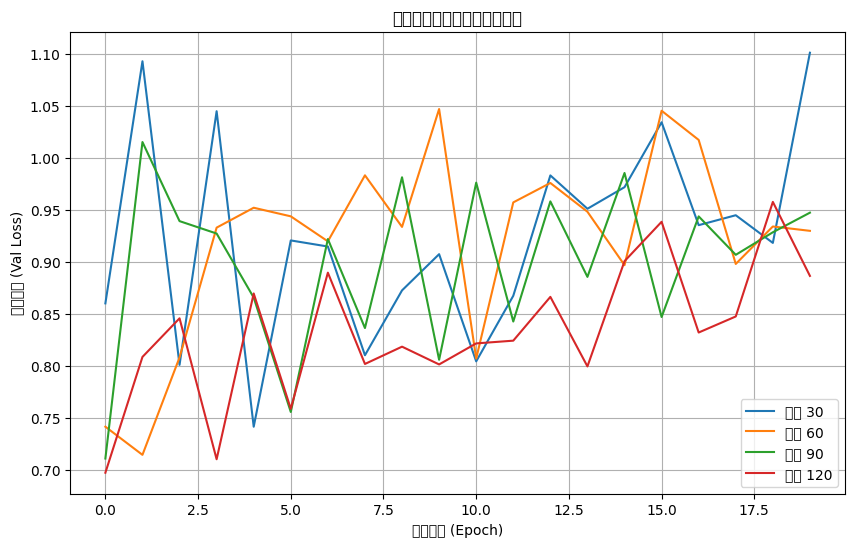

In [30]:
import matplotlib.pyplot as plt

# 绘制验证损失曲线
plt.figure(figsize=(10, 6))
for window_size, history in histories.items():
    plt.plot(history.history['val_loss'], label=f'窗口 {window_size}')
plt.title('不同窗口大小的验证损失对比')
plt.xlabel('训练轮数 (Epoch)')
plt.ylabel('验证损失 (Val Loss)')
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


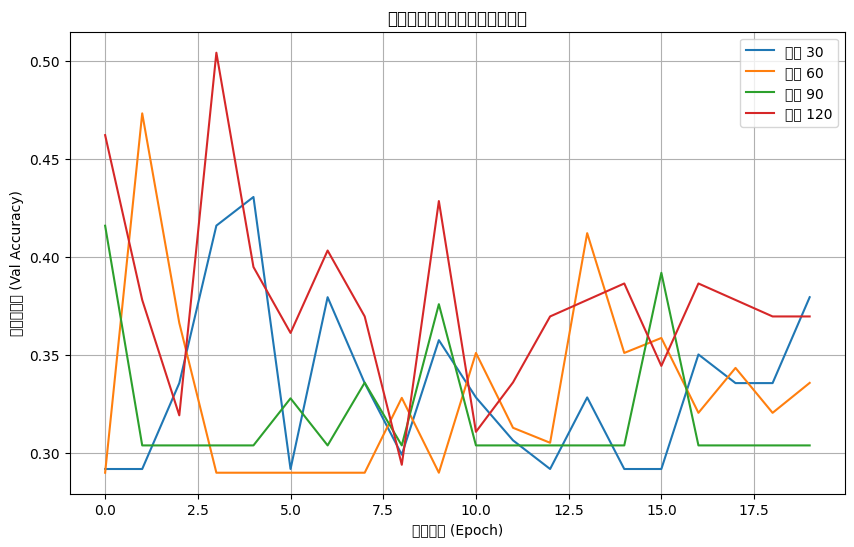

In [31]:
# 绘制验证准确率曲线
plt.figure(figsize=(10, 6))
for window_size, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=f'窗口 {window_size}')
plt.title('不同窗口大小的验证准确率对比')
plt.xlabel('训练轮数 (Epoch)')
plt.ylabel('验证准确率 (Val Accuracy)')
plt.legend()
plt.grid(True)
plt.show()


In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import os

def add_indicators_and_prepare_lstm_input(df, window_size=60, target_shift=1):
    df = df.copy()

    # 技术指标
    close = df['Close']
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9, adjust=False).mean()
    delta = close.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    # Handle division by zero for RSI
    rs = np.where(avg_loss == 0, np.inf, avg_gain / avg_loss)
    rsi = 100 - (100 / (1 + rs))


    df['MACD'] = macd
    df['MACD_signal'] = signal
    df['RSI'] = rsi
    df = df.dropna().reset_index(drop=True)

    # 标准化
    features = ['Close', 'MACD', 'MACD_signal', 'RSI']
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[features])

    # 构造时间窗口
    X, y = [], []
    for i in range(len(scaled) - window_size - target_shift):
        X.append(scaled[i:i+window_size])
        y.append(scaled[i+window_size+target_shift-1][0])  # 预测未来的 Close

    return np.array(X), np.array(y), scaler # Return scaler

def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def train_lstm_with_indicators(df, window_size=60, target_shift=1, batch_size=60, epochs=100, model_path='best_model.h5'):
    # 构造数据
    X, y, scaler = add_indicators_and_prepare_lstm_input(df, window_size, target_shift) # Get scaler here
    split = int(len(X) * 0.8)
    X_train, X_val = X[:split], X[split:]
    y_train, y_val = y[:split], y[split:]

    # 构建模型
    model = build_lstm_model(X_train.shape[1:])

    # 回调函数
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    checkpoint = ModelCheckpoint(model_path, monitor='val_loss', save_best_only=True, verbose=1)

    # 训练
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, checkpoint],
        verbose=1
    )

    # 最佳 epoch 和验证损失
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val_loss = np.min(history.history['val_loss'])

    print(f"\n✅ Best Epoch: {best_epoch}")
    print(f"📉 Best Validation Loss: {best_val_loss:.4f}")
    print(f"💾 Model saved to: {os.path.abspath(model_path)}")

    # 可视化
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.axvline(best_epoch - 1, color='red', linestyle='--', label='Best Epoch')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    return model, history, scaler # Return scaler here

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.5953
Epoch 1: val_loss improved from inf to 0.28268, saving model to best_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.5841 - val_loss: 0.2827
Epoch 2/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1485
Epoch 2: val_loss improved from 0.28268 to 0.10813, saving model to best_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1464 - val_loss: 0.1081
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1029
Epoch 3: val_loss improved from 0.10813 to 0.08899, saving model to best_model.h5


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0375 - val_loss: 0.0677
Epoch 26/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0375
Epoch 26: val_loss did not improve from 0.06771
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0375 - val_loss: 0.0678
Epoch 27/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0352
Epoch 27: val_loss did not improve from 0.06771
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0351 - val_loss: 0.0698
Epoch 28/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0380
Epoch 28: val_loss improved from 0.06771 to 0.06212, saving model to best_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0379 - val_loss: 0.0621
Epoch 29/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0336
Epoch 29: val_loss did not improve from 0.06212
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0337 - val_loss: 0.0708
Epoch 30/100
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0326
Epoch 30: val_loss did not improve from 0.06212
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0327 - val_loss: 0.0703
Epoch 31/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0334
Epoch 31: val_loss did not improve from 0.06212
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0336 - val_loss: 0.0652
Epoch 32/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0302
Epoch 32: val_loss did not improve from 0.06212
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0311 - val_loss: 0.0671
Epoch 33/100
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0295
Epoch 33: val_loss did not improve from 0.06212
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0301 - val_loss: 0.070

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0307 - val_loss: 0.0616
Epoch 36/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0325
Epoch 36: val_loss did not improve from 0.06162
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0325 - val_loss: 0.0713
Epoch 37/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0316
Epoch 37: val_loss did not improve from 0.06162
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0318 - val_loss: 0.0647
Epoch 38/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0283
Epoch 38: val_loss did not improve from 0.06162
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0298 - val_loss: 0.0627
Epoch 39/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0298
Epoch 39: val_loss did not improve from 0.06162
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0307 - val_loss: 0.0630
Epoch 40/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0308
Epoch 40: val_loss did not improve from 0.06162
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0310 - val_loss: 0.066

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0365 - val_loss: 0.0603
Epoch 42/100
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0330
Epoch 42: val_loss did not improve from 0.06027
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0329 - val_loss: 0.0655
Epoch 43/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0292
Epoch 43: val_loss did not improve from 0.06027
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0290 - val_loss: 0.0631
Epoch 44/100
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0313
Epoch 44: val_loss did not improve from 0.06027
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0311 - val_loss: 0.0615
Epoch 45/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0318
Epoch 45: val_loss did not improve from 0.06027
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0319 - val_loss: 0.0694
Epoch 46/100
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0301
Epoch 46: val_loss did not improve from 0.06027
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0303 - val_loss: 0.061

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0290 - val_loss: 0.0571
Epoch 49/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0257
Epoch 49: val_loss did not improve from 0.05710
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0264 - val_loss: 0.0669
Epoch 50/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0264
Epoch 50: val_loss did not improve from 0.05710
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0275 - val_loss: 0.0590
Epoch 51/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0315
Epoch 51: val_loss did not improve from 0.05710
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0309 - val_loss: 0.0660
Epoch 52/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0280
Epoch 52: val_loss did not improve from 0.05710
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0281 - val_loss: 0.0613
Epoch 53/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0283
Epoch 53: val_loss did not improve from 0.05710
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0284 - val_loss: 0.063

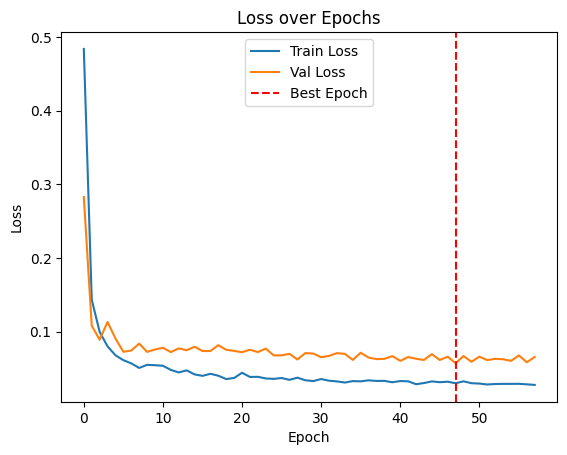

In [34]:
model, history = train_lstm_with_indicators(df, window_size=60, target_shift=1, batch_size=60, epochs=100)


In [1]:
    # 🔮 训练完成后预测未来收盘价
    future_predictions = predict_future_close(df, model, scaler, window_size=window_size, predict_days=15)

    # 📊 可视化预测结果
    last_date = df.index[-1] if df.index.is_monotonic_increasing else pd.date_range(end=pd.Timestamp.today(), periods=len(df))[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=15)

    plt.figure(figsize=(10, 5))
    plt.plot(df['Close'], label='Historical Close')
    plt.plot(future_dates, future_predictions, label='Predicted Future Close', linestyle='--', marker='o')
    plt.title('Future 15-Day Close Price Prediction')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


NameError: name 'predict_future_close' is not defined

In [57]:
def predict_future_close(df, model, scaler, window_size=60, predict_days=15):
    df = df.copy()

    # Add technical indicators
    df = add_technical_indicators(df)

    # Select features and standardize
    features = ['Close', 'MACD', 'MACD_signal', 'RSI']
    scaled_data = scaler.transform(df[features])

    predictions = []
    # Get the last window_size days of scaled data as the initial input sequence
    input_seq = scaled_data[-window_size:].copy()

    for _ in range(predict_days):
        # Reshape the input sequence for the LSTM model (1 sample, window_size time steps, number of features)
        input_reshaped = input_seq.reshape(1, window_size, -1)
        pred_scaled = model.predict(input_reshaped, verbose=0)[0][0]

        # Inverse transform the predicted value (only for Close)
        # To do this accurately, we need a dummy array with the predicted Close and mean values for other features
        # However, the scaler was fitted on features including MACD, Signal, RSI which are dependent on Close.
        # A simpler approach is to only inverse transform the 'Close' part if we know its index.
        # Assuming 'Close' is the first feature in the 'features' list used for scaling:
        close_idx = features.index('Close')
        # Create a dummy array with the predicted scaled Close value and mean values for other features
        dummy_row = np.zeros(len(features))
        dummy_row[close_idx] = pred_scaled
        # Reshape the dummy row to be 2D for inverse transform
        dummy_row = dummy_row.reshape(1, -1)
        pred_unscaled = scaler.inverse_transform(dummy_row)[0][close_idx]
        predictions.append(pred_unscaled)

        # Construct the next input sequence by removing the first time step and adding the predicted scaled values
        # We need to predict all features for the next step to use as input, but the model only predicts Close.
        # A common workaround is to append the predicted Close and assume other indicators remain relatively stable or use a different method to predict them.
        # For simplicity here, we will append the predicted scaled Close and assume other indicators from the last known data point.
        # This is a simplification and might not be the most accurate for multi-feature prediction.
        # A better approach would be to predict all features or use a multi-output model.

        # Simplified approach: Use the predicted scaled Close and the last known scaled values for other features
        next_step_input = np.zeros(len(features))
        next_step_input[close_idx] = pred_scaled
        # Assuming the other features will be the same as the last data point in the window - NOT ideal but a workaround
        # For a more robust solution, one might predict other features or use a different model architecture.
        last_known_features_scaled = input_seq[-1, :]
        next_step_input = last_known_features_scaled.copy()
        next_step_input[close_idx] = pred_scaled


        input_seq = np.vstack([input_seq[1:], next_step_input.reshape(1, -1)])


    return predictions

In [58]:
def add_technical_indicators(df):
    df = df.copy()
    close = df['Close']

    # MACD
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # RSI
    delta = close.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))

    return df.dropna().reset_index(drop=True)


In [55]:
df_original = df.copy() # Keep a copy of the original dataframe
df = add_technical_indicators(df)

In [48]:
def plot_predictions(df, predictions):
    recent_closes = df['Close'].values[-60:]
    future_days = list(range(len(recent_closes), len(recent_closes) + len(predictions)))

    plt.plot(range(len(recent_closes)), recent_closes, label='Recent Close')
    plt.plot(future_days, predictions, label='Predicted Close', linestyle='--', color='red')
    plt.title('15-Day Close Price Forecast')
    plt.xlabel('Day')
    plt.ylabel('Price')
    plt.legend()
    plt.show()


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.5219
Epoch 1: val_loss improved from inf to 0.24831, saving model to best_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.5144 - val_loss: 0.2483
Epoch 2/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1373
Epoch 2: val_loss improved from 0.24831 to 0.09663, saving model to best_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1344 - val_loss: 0.0966
Epoch 3/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1155
Epoch 3: val_loss did not improve from 0.09663
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1135 - val_loss: 0.1082
Epoch 4/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0709
Epoch 4: val_loss did not improve from 0.09663
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0729 - val_loss: 0.1253
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0716
Epoch 5: val_loss did not improve from 0.09663
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0719 - val_loss: 0.1030
Epoch 6/100
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0866
Epoch 6: val_loss did not improve from 0.09663
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0835 - val_loss: 0.1007
Epoch 7/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0561
Epoch 7: val_loss did not improve from 0.09663
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0571 - val_loss: 0.0971
Epoch 8/

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0661 - val_loss: 0.0944
Epoch 9/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0528
Epoch 9: val_loss did not improve from 0.09441
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0536 - val_loss: 0.0949
Epoch 10/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0580
Epoch 10: val_loss improved from 0.09441 to 0.08807, saving model to best_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0570 - val_loss: 0.0881
Epoch 11/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0453
Epoch 11: val_loss did not improve from 0.08807
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0459 - val_loss: 0.0982
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0520
Epoch 12: val_loss did not improve from 0.08807
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0521 - val_loss: 0.1118
Epoch 13/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0422
Epoch 13: val_loss did not improve from 0.08807
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0445 - val_loss: 0.0918
Epoch 14/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0520
Epoch 14: val_loss did not improve from 0.08807
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0503 - val_loss: 0.0985
Epoch 15/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0533
Epoch 15: val_loss did not improve from 0.08807
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0515 - val_loss: 0.096

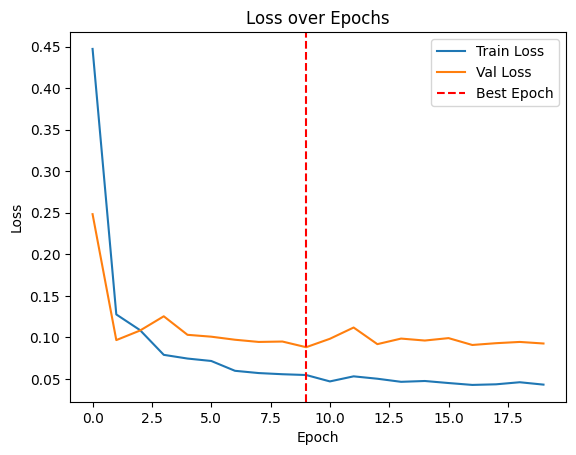

In [59]:
model, history, scaler = train_lstm_with_indicators(df) # Removed return_scaler=True

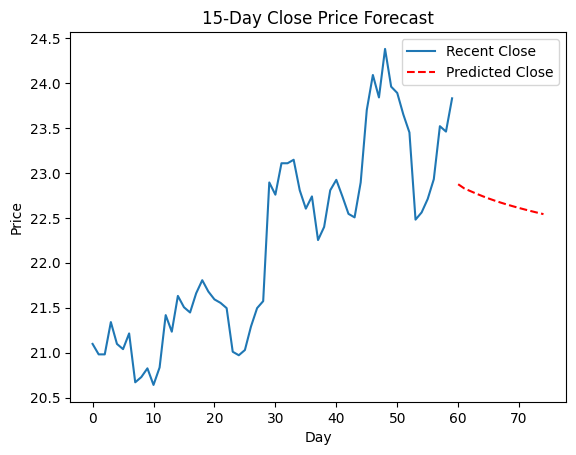

In [60]:
# Use the scaler returned by train_lstm_with_indicators
predictions = predict_future_close(df_original, model, scaler, window_size=60, predict_days=15)
plot_predictions(df, predictions)

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  fig.canvas

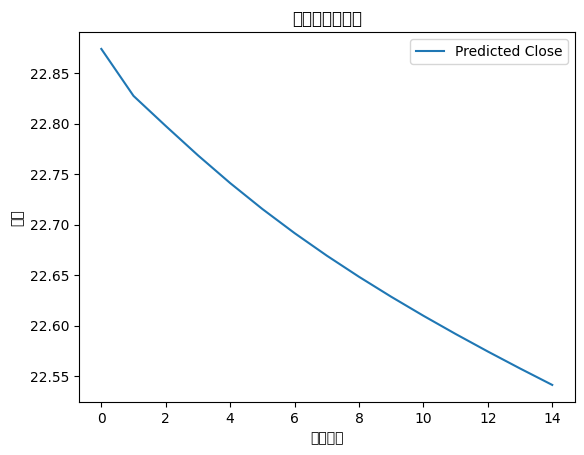

In [61]:
plt.plot(predictions, label='Predicted Close')
plt.title('未来收盘价预测')
plt.xlabel('预测天数')
plt.ylabel('价格')
plt.legend()
plt.tight_layout()
plt.show()


In [62]:
def predict_future_close(df, model, scaler, window_size=60, predict_days=60):
    df = df.copy()
    df = add_technical_indicators(df)

    features = ['Close', 'MACD', 'MACD_signal', 'RSI']
    scaled_data = scaler.transform(df[features])

    predictions = []
    input_seq = scaled_data[-window_size:].copy()

    for _ in range(predict_days):
        input_reshaped = input_seq.reshape(1, window_size, -1)
        pred_scaled = model.predict(input_reshaped, verbose=0)[0][0]

        # 反标准化 Close
        dummy_row = np.zeros(len(features))
        dummy_row[0] = pred_scaled
        pred_unscaled = scaler.inverse_transform(dummy_row.reshape(1, -1))[0][0]
        predictions.append(pred_unscaled)

        # 构造下一步输入（简化处理）
        next_step_input = input_seq[-1].copy()
        next_step_input[0] = pred_scaled
        input_seq = np.vstack([input_seq[1:], next_step_input.reshape(1, -1)])

    return predictions


In [68]:
def plot_predictions(df, predictions):
    plt.figure(figsize=(10, 5))
    plt.plot(df['Close'], label='历史收盘价')
    future_index = range(len(df), len(df) + len(predictions))
    plt.plot(future_index, predictions, label='预测收盘价', linestyle='--', color='red')
    plt.title('未来收盘价预测（60天）')
    plt.xlabel('时间')
    plt.ylabel('价格')
    plt.axvline(x=len(df), color='gray', linestyle='--', label='预测起点')

    plt.legend()
    plt.grid(True)
    plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  fig.canvas

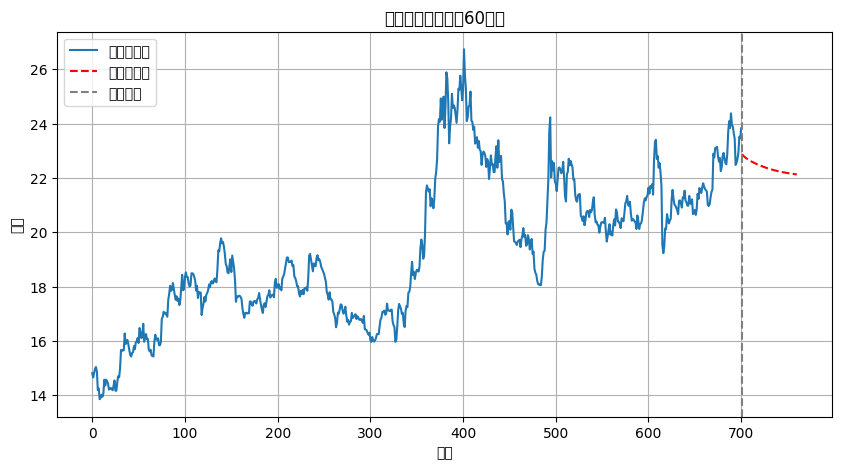

In [69]:
predictions = predict_future_close(df, model, scaler, window_size=60, predict_days=60)
plot_predictions(df, predictions)
